# Model Training

This notebook trains multiple machine learning models for customer churn prediction.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef)
from sklearn.model_selection import cross_val_score, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load preprocessed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (5616, 6559)
Test set: (1405, 6559)


## Model Training with Multiple Algorithms

In [3]:
# Define models to train
# Note: SVM optimized with linear kernel for faster training
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(random_state=42, kernel='linear', probability=True, max_iter=1000)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Get prediction probabilities for AUC calculation
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)
        # For binary classification, use positive class probabilities
        if y_pred_proba.shape[1] == 2:
            auc = roc_auc_score(y_test, y_pred_proba[:, 1])
        else:
            # For multi-class, use ovr (one-vs-rest) approach
            auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    else:
        auc = None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_test, y_pred)
    
    results[name] = {
        'Accuracy': accuracy,
        'AUC': auc if auc is not None else 'N/A',
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'MCC': mcc,
        'Model': model
    }
    
    print(f"{name} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}, MCC: {mcc:.4f}")


Training Logistic Regression...
Logistic Regression - Accuracy: 0.7851, F1-Score: 0.7777, MCC: 0.4173

Training Decision Tree...
Decision Tree - Accuracy: 0.7730, F1-Score: 0.7692, MCC: 0.3996

Training Random Forest...
Random Forest - Accuracy: 0.7907, F1-Score: 0.7788, MCC: 0.4190

Training K-Nearest Neighbors...
K-Nearest Neighbors - Accuracy: 0.7352, F1-Score: 0.6295, MCC: 0.0451

Training Naive Bayes...
Naive Bayes - Accuracy: 0.2797, F1-Score: 0.1679, MCC: -0.0428

Training Support Vector Machine...
Support Vector Machine - Accuracy: 0.7317, F1-Score: 0.7409, MCC: 0.3725


In [4]:
# Display results comparison
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results],
    'AUC': [results[m]['AUC'] for m in results],
    'Precision': [results[m]['Precision'] for m in results],
    'Recall': [results[m]['Recall'] for m in results],
    'F1-Score': [results[m]['F1-Score'] for m in results],
    'MCC': [results[m]['MCC'] for m in results]
})

results_df = results_df.sort_values('F1-Score', ascending=False)
print("\n" + "="*100)
print("Model Performance Comparison - All Required Metrics")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)


Model Performance Comparison - All Required Metrics
                 Model  Accuracy      AUC  Precision   Recall  F1-Score       MCC
         Random Forest  0.790747 0.831055   0.777464 0.790747  0.778760  0.418973
   Logistic Regression  0.785053 0.812181   0.774559 0.785053  0.777667  0.417269
         Decision Tree  0.772954 0.695223   0.766586 0.772954  0.769241  0.399603
Support Vector Machine  0.731673 0.780537   0.757914 0.731673  0.740948  0.372501
   K-Nearest Neighbors  0.735231 0.538465   0.674189 0.735231  0.629516  0.045140
           Naive Bayes  0.279715 0.489523   0.548465 0.279715  0.167938 -0.042781


## Hyperparameter Tuning for Best Model

In [5]:
# Select the best model for hyperparameter tuning
best_model_name = results_df.iloc[0]['Model']
print(f"Best performing model: {best_model_name}")

# Example: Hyperparameter tuning for Random Forest
if 'Random Forest' in best_model_name:
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )
    
    print("\nPerforming Grid Search...")
    grid_search.fit(X_train, y_train)
    
    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    
    # Use the best model
    best_model = grid_search.best_estimator_
else:
    # Use the best model without tuning
    best_model = results[best_model_name]['Model']

Best performing model: Random Forest

Performing Grid Search...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.7911


## Cross-Validation

In [6]:
# Perform cross-validation on the best model
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1_weighted')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-validation scores: [0.79274513 0.78786227 0.79213509 0.79062853 0.79217011]
Mean CV score: 0.7911 (+/- 0.0035)


## Save Best Model

In [7]:
# Save the best model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature names for later use
feature_names = X_train.columns.tolist()
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("\nBest model saved successfully!")
print(f"Model type: {type(best_model).__name__}")


Best model saved successfully!
Model type: RandomForestClassifier


## Feature Importance (if applicable)

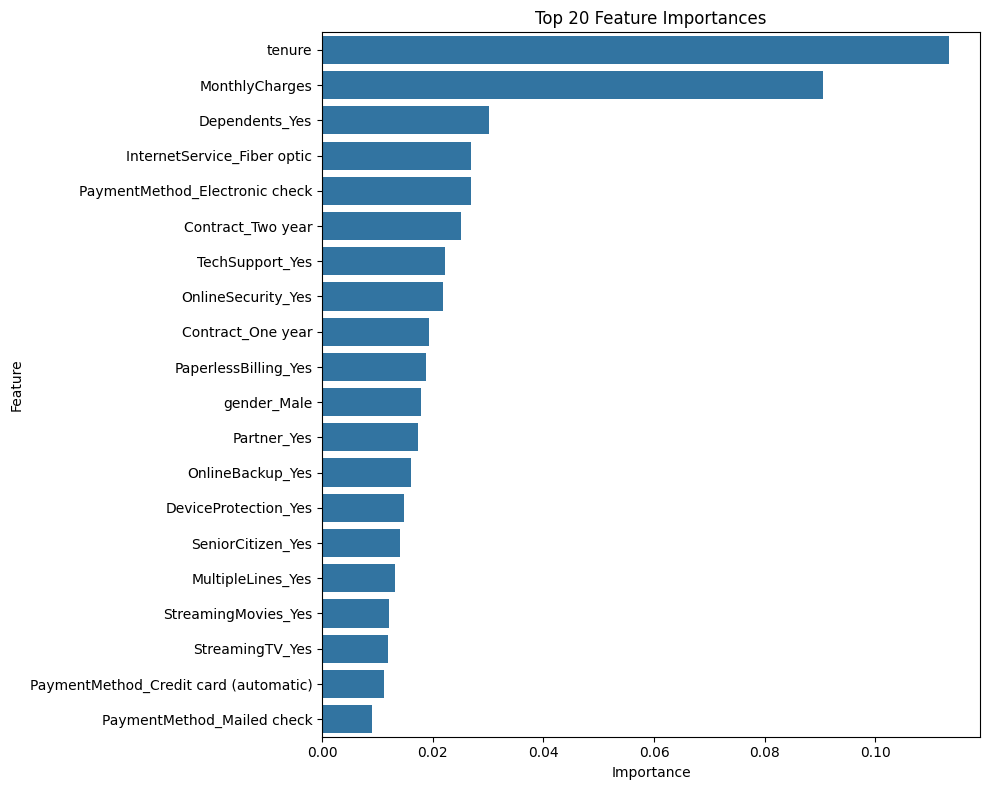


Top 10 Most Important Features:
                       Feature  Importance
                        tenure    0.113225
                MonthlyCharges    0.090584
                Dependents_Yes    0.030179
   InternetService_Fiber optic    0.026991
PaymentMethod_Electronic check    0.026882
             Contract_Two year    0.025130
               TechSupport_Yes    0.022161
            OnlineSecurity_Yes    0.021888
             Contract_One year    0.019362
          PaperlessBilling_Yes    0.018718


In [8]:
# Display feature importance for tree-based models
import matplotlib.pyplot as plt
import seaborn as sns

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance.head(20), x='Importance', y='Feature')
    plt.title('Top 20 Feature Importances')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))